In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
import os
path = '/content/drive/MyDrive/rag-complaint-chatbot/data/raw/complaints.csv'
print("Exists:", os.path.exists(path))
if os.path.exists(path):
    size = os.path.getsize(path) / (1024**3)
    print(f"Size: {size:.2f} GB")
else:
    print("File not found. We'll download it.")

Exists: False
File not found. We'll download it.


In [3]:
!pip install gdown -q
import gdown

file_id = '1wBM-ncQ3GsjivtrvxROt1mchy__Jn7_0'
gdown.download(f'https://drive.google.com/uc?id={file_id}', 'complaints.csv', quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1wBM-ncQ3GsjivtrvxROt1mchy__Jn7_0
From (redirected): https://drive.google.com/uc?id=1wBM-ncQ3GsjivtrvxROt1mchy__Jn7_0&confirm=t&uuid=6f8752fb-4c4b-45f5-8901-3c185ceed002
To: /content/complaints.csv
100%|██████████| 6.04G/6.04G [01:22<00:00, 72.8MB/s]


'complaints.csv'

In [5]:
import os
if os.path.exists('complaints.csv'):
    size = os.path.getsize('complaints.csv') / (1024**3)
    print(f" File downloaded: {size:.2f} GB")
else:
    print(" Download failed. Check sharing permissions.")

 File downloaded: 5.63 GB


In [9]:
import pandas as pd

#load in chunks to avoid memory issues
chunk_size = 100000
chunks = []
for chunk in pd.read_csv('complaints.csv', chunksize=chunk_size, low_memory=False):
    chunks.append(chunk)
df = pd.concat(chunks, ignore_index=True)

print(f" Loaded {len(df):,} records")
print(f"Columns: {df.columns.tolist()}")

 Loaded 9,609,797 records
Columns: ['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue', 'Consumer complaint narrative', 'Company public response', 'Company', 'State', 'ZIP code', 'Tags', 'Consumer consent provided?', 'Submitted via', 'Date sent to company', 'Company response to consumer', 'Timely response?', 'Consumer disputed?', 'Complaint ID']


In [10]:
print("Dataset Info:")
print(f"Total records: {len(df):,}")
print(f"Total columns: {len(df.columns)}")
print(f"Column names: {df.columns.tolist()[:10]}...")

Dataset Info:
Total records: 9,609,797
Total columns: 18
Column names: ['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue', 'Consumer complaint narrative', 'Company public response', 'Company', 'State', 'ZIP code']...


In [11]:
print("="*60)
print("FULL DATASET INFORMATION")
print("="*60)
print(f"Total records: {len(df):,}")
print(f"Total columns: {len(df.columns)}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**3:.2f} GB")
print(f"\nAll columns:\n{df.columns.tolist()}")

print("\n" + "="*60)
print("DATA TYPES")
print("="*60)
print(df.dtypes)

FULL DATASET INFORMATION
Total records: 9,609,797
Total columns: 18
Memory usage: 12.37 GB

All columns:
['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue', 'Consumer complaint narrative', 'Company public response', 'Company', 'State', 'ZIP code', 'Tags', 'Consumer consent provided?', 'Submitted via', 'Date sent to company', 'Company response to consumer', 'Timely response?', 'Consumer disputed?', 'Complaint ID']

DATA TYPES
Date received                   object
Product                         object
Sub-product                     object
Issue                           object
Sub-issue                       object
Consumer complaint narrative    object
Company public response         object
Company                         object
State                           object
ZIP code                        object
Tags                            object
Consumer consent provided?      object
Submitted via                   object
Date sent to company            object
Company res

MISSING VALUES ANALYSIS
                              Missing Count  Missing %
Tags                                8981029  93.457011
Consumer disputed?                  8841498  92.005044
Consumer complaint narrative        6629041  68.982113
Company public response             4770207  49.638999
Consumer consent provided?          1649561  17.165409
Sub-issue                            839522   8.736105
Sub-product                          235295   2.448491
State                                 54516   0.567296
ZIP code                              30228   0.314554
Company response to consumer             20   0.000208
Issue                                     6   0.000062


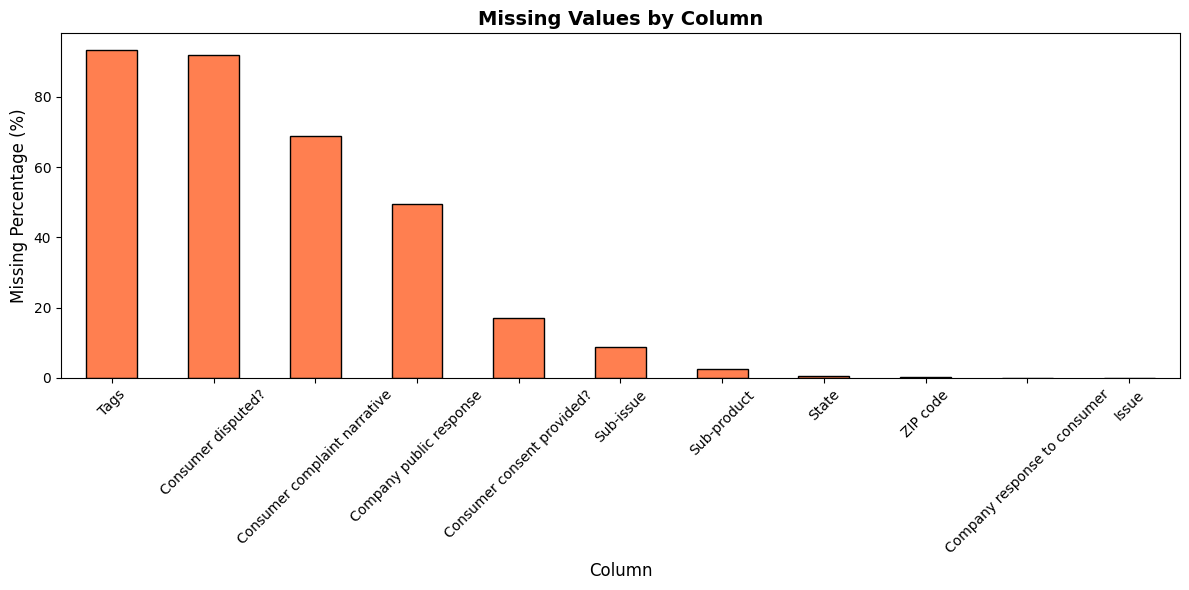

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

print("="*60)
print("MISSING VALUES ANALYSIS")
print("="*60)
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)

print(missing_df[missing_df['Missing %'] > 0])

fig, ax = plt.subplots(figsize=(12, 6))
missing_df[missing_df['Missing %'] > 0]['Missing %'].plot(kind='bar', color='coral', edgecolor='black')
ax.set_title('Missing Values by Column', fontsize=14, fontweight='bold')
ax.set_xlabel('Column', fontsize=12)
ax.set_ylabel('Missing Percentage (%)', fontsize=12)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('missing_values.png', dpi=300, bbox_inches='tight')
plt.show()

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

plt.style.use('default')
sns.set_theme(style="whitegrid")
sns.set_palette("husl")

print("All imports loaded successfully!")

All imports loaded successfully!


PRODUCT DISTRIBUTION
Credit reporting or other personal consumer reports: 4,834,855 (50.31%)
Credit reporting, credit repair services, or other personal consumer reports: 2,163,857 (22.52%)
Debt collection: 799,197 (8.32%)
Mortgage: 422,254 (4.39%)
Checking or savings account: 291,178 (3.03%)
Credit card: 226,686 (2.36%)
Credit card or prepaid card: 206,369 (2.15%)
Money transfer, virtual currency, or money service: 145,066 (1.51%)
Credit reporting: 140,429 (1.46%)
Student loan: 109,717 (1.14%)
Bank account or service: 86,205 (0.90%)
Vehicle loan or lease: 72,957 (0.76%)
Consumer Loan: 31,574 (0.33%)
Payday loan, title loan, or personal loan: 30,641 (0.32%)
Payday loan, title loan, personal loan, or advance loan: 16,514 (0.17%)
Prepaid card: 15,280 (0.16%)
Payday loan: 5,541 (0.06%)
Money transfers: 5,354 (0.06%)
Debt or credit management: 5,047 (0.05%)
Other financial service: 1,058 (0.01%)
Virtual currency: 18 (0.00%)

Found 'Credit card' as: ['Credit card', 'Credit card or prepaid c

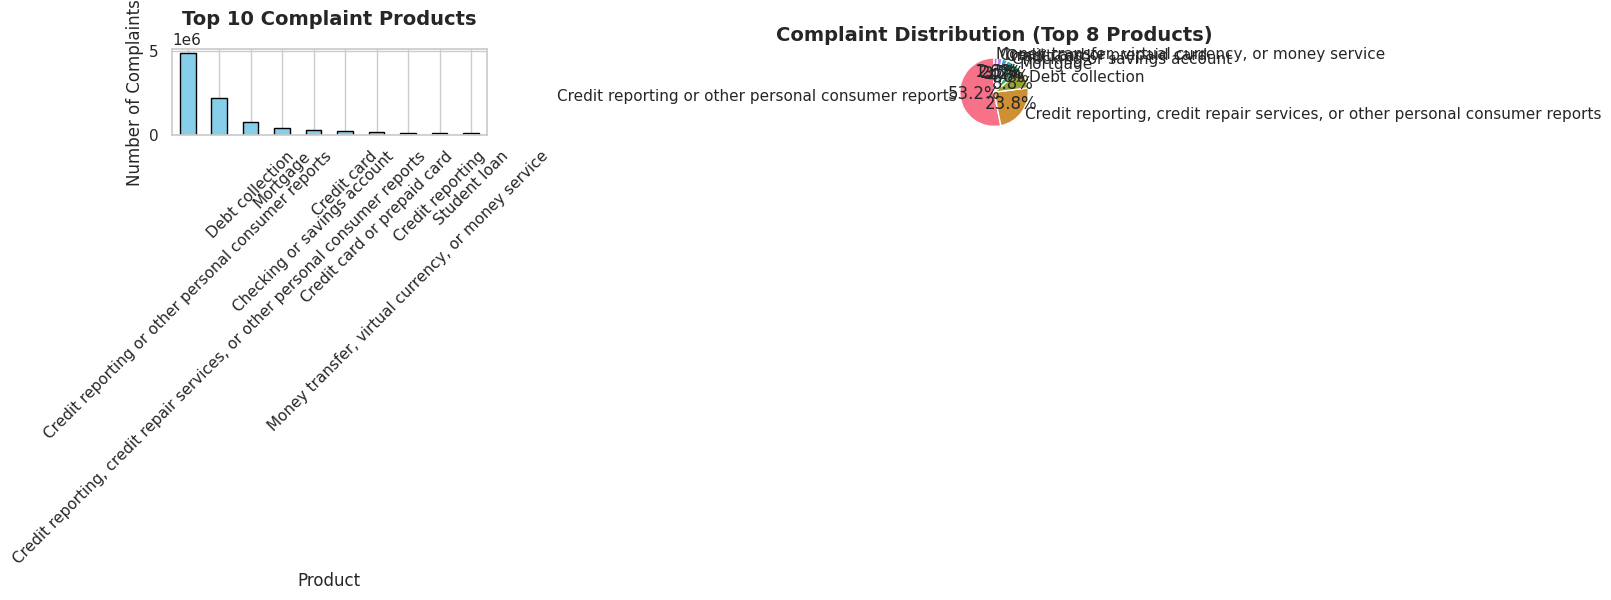

In [16]:
print("="*60)
print("PRODUCT DISTRIBUTION")
print("="*60)
product_stats = df['Product'].value_counts()
for product, count in product_stats.items():
    pct = (count / len(df)) * 100
    print(f"{product}: {count:,} ({pct:.2f}%)")

TARGET_PRODUCTS = ['Credit card', 'Personal loan', 'Savings account', 'Money transfer']
available_products = df['Product'].unique().tolist()

available_targets = []
for target in TARGET_PRODUCTS:
    matches = [p for p in available_products if target.lower() in p.lower()]
    if matches:
        available_targets.extend(matches)
        print(f"\nFound '{target}' as: {matches}")

print(f"\nTarget products to use: {available_targets}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

product_stats.head(10).plot(kind='bar', ax=axes[0], color='skyblue', edgecolor='black')
axes[0].set_title('Top 10 Complaint Products', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Product', fontsize=12)
axes[0].set_ylabel('Number of Complaints', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

top_products = product_stats.head(8)
colors = sns.color_palette("husl", len(top_products))
axes[1].pie(top_products.values, labels=top_products.index,
            autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Complaint Distribution (Top 8 Products)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('product_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

NARRATIVE LENGTH ANALYSIS
With narratives: 2,980,756 (31.02%)
Empty narratives: 6,629,041 (68.98%)

Narrative Length Statistics:
  Mean: 1000 characters
  Median: 659 characters
  Min: 4 characters
  Max: 35722 characters
  Q1: 333 characters
  Q3: 1189 characters


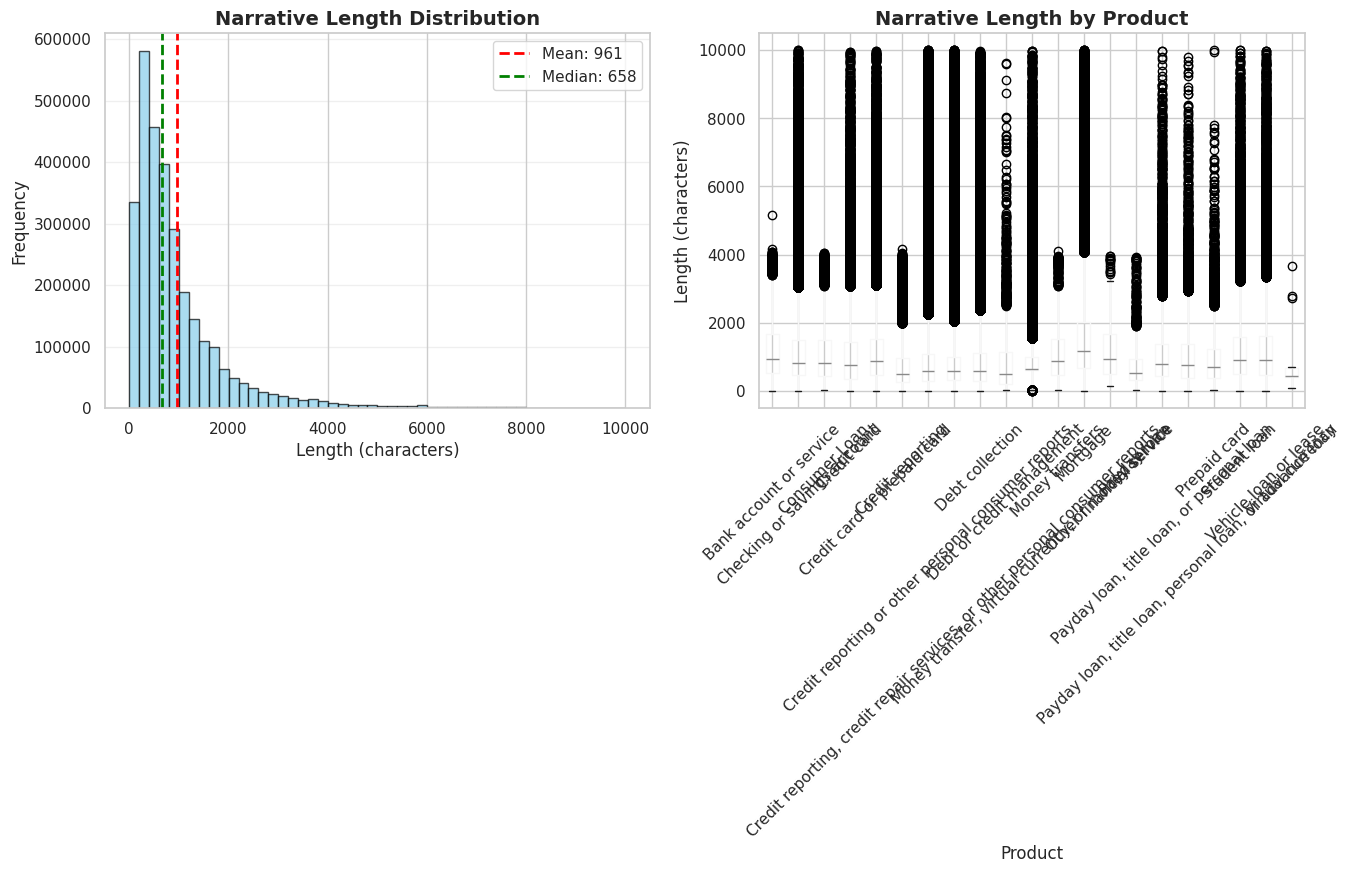

In [17]:
print("="*60)
print("NARRATIVE LENGTH ANALYSIS")
print("="*60)

empty_narratives = df['Consumer complaint narrative'].isna().sum()
empty_pct = (empty_narratives / len(df)) * 100
non_empty = len(df) - empty_narratives

print(f"With narratives: {non_empty:,} ({100-empty_pct:.2f}%)")
print(f"Empty narratives: {empty_narratives:,} ({empty_pct:.2f}%)")

non_empty_df = df[df['Consumer complaint narrative'].notna()]
lengths = non_empty_df['Consumer complaint narrative'].str.len()

print(f"\nNarrative Length Statistics:")
print(f"  Mean: {lengths.mean():.0f} characters")
print(f"  Median: {lengths.median():.0f} characters")
print(f"  Min: {lengths.min():.0f} characters")
print(f"  Max: {lengths.max():.0f} characters")
print(f"  Q1: {lengths.quantile(0.25):.0f} characters")
print(f"  Q3: {lengths.quantile(0.75):.0f} characters")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

filtered_lengths = lengths[lengths < 10000]
axes[0].hist(filtered_lengths, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].axvline(filtered_lengths.mean(), color='red', linestyle='--', linewidth=2,
                label=f'Mean: {filtered_lengths.mean():.0f}')
axes[0].axvline(filtered_lengths.median(), color='green', linestyle='--', linewidth=2,
                label=f'Median: {filtered_lengths.median():.0f}')
axes[0].set_title('Narrative Length Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Length (characters)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

df['narrative_len'] = df['Consumer complaint narrative'].str.len()
products_with_data = df[df['narrative_len'] < 10000].copy()
products_with_data.boxplot(column='narrative_len', by='Product', ax=axes[1], rot=45)
axes[1].set_title('Narrative Length by Product', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Product', fontsize=12)
axes[1].set_ylabel('Length (characters)', fontsize=12)

plt.suptitle('')
plt.tight_layout()
plt.savefig('narrative_length_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

TOP 10 COMPLAINT ISSUES
Incorrect information on your report: 3,613,761 (37.60%)
Improper use of your report: 1,841,256 (19.16%)
Problem with a company's investigation into an existing problem: 928,220 (9.66%)
Problem with a credit reporting company's investigation into an existing problem: 589,334 (6.13%)
Attempts to collect debt not owed: 314,690 (3.27%)
Managing an account: 171,233 (1.78%)
Written notification about debt: 161,161 (1.68%)
Loan modification,collection,foreclosure: 112,306 (1.17%)
Incorrect information on credit report: 102,684 (1.07%)
Trouble during payment process: 94,390 (0.98%)

Total unique issues: 173


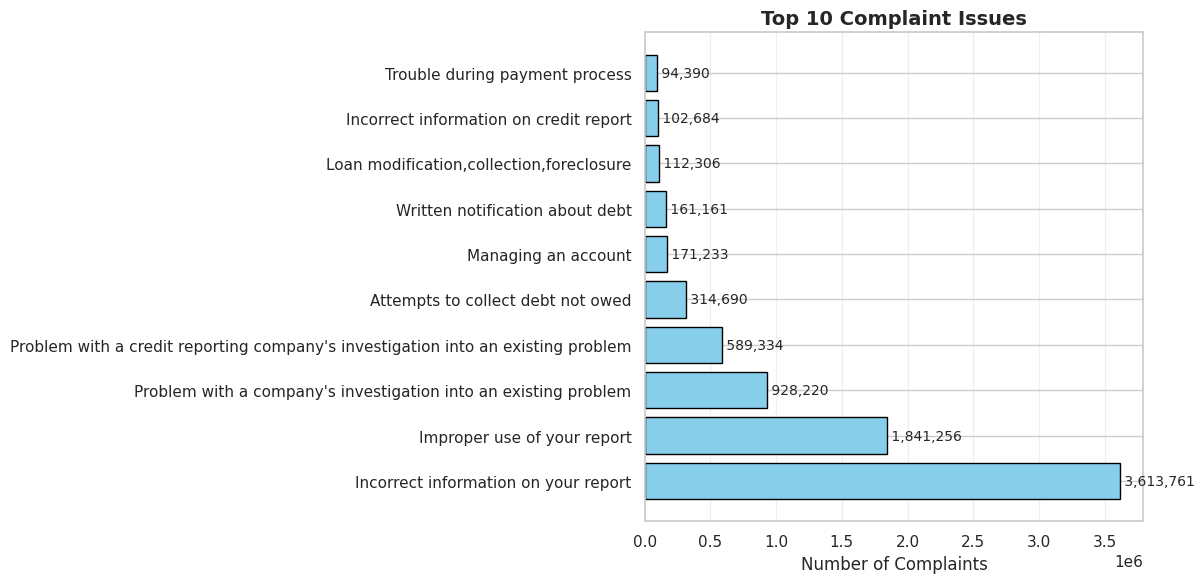

In [18]:
print("="*60)
print("TOP 10 COMPLAINT ISSUES")
print("="*60)
issue_counts = df['Issue'].value_counts()
for issue, count in issue_counts.head(10).items():
    pct = (count / len(df)) * 100
    print(f"{issue}: {count:,} ({pct:.2f}%)")

print(f"\nTotal unique issues: {issue_counts.nunique()}")

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(issue_counts.head(10).index, issue_counts.head(10).values,
               color='skyblue', edgecolor='black')
ax.set_title('Top 10 Complaint Issues', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Complaints', fontsize=12)
ax.grid(axis='x', alpha=0.3)

for i, (bar, count) in enumerate(zip(bars, issue_counts.head(10).values)):
    ax.text(count, i, f' {count:,}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('top_issues.png', dpi=300, bbox_inches='tight')
plt.show()

In [19]:
import re

print("="*60)
print("FILTERING AND PREPROCESSING")
print("="*60)

filtered_df = df[df['Product'].isin(available_targets)].copy()
print(f"Records after product filtering: {len(filtered_df):,}")

filtered_df = filtered_df[filtered_df['Consumer complaint narrative'].notna()]
filtered_df = filtered_df[filtered_df['Consumer complaint narrative'].str.strip() != '']
print(f"Records after removing empty narratives: {len(filtered_df):,}")

def clean_text(text):
    if pd.isna(text) or not isinstance(text, str):
        return ""
    text = text.lower()
    boilerplate_patterns = [
        r'i am writing to file a complaint',
        r'i am writing to complain about',
        r'i am submitting a complaint',
        r'this is a complaint regarding',
        r'i would like to file a complaint',
        r'please find below my complaint',
        r'i am filing a complaint',
        r'complaint:',
        r'dear [a-z\s]+,\s*'
    ]
    for pattern in boilerplate_patterns:
        text = re.sub(pattern, '', text, flags=re.IGNORECASE)
    text = re.sub(r'[^a-zA-Z0-9\s\.\,\!\?\'\"]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

print("Cleaning narratives...")
filtered_df['cleaned_narrative'] = filtered_df['Consumer complaint narrative'].apply(clean_text)
filtered_df['narrative_length'] = filtered_df['cleaned_narrative'].str.len()

filtered_df = filtered_df[filtered_df['narrative_length'] >= 10]
filtered_df = filtered_df[filtered_df['narrative_length'] <= 5000]
print(f"Records after length filtering: {len(filtered_df):,}")

FILTERING AND PREPROCESSING
Records after product filtering: 921,808
Records after removing empty narratives: 454,472
Cleaning narratives...
Records after length filtering: 447,588


In [20]:
print("="*60)
print("FINAL DATASET STATISTICS")
print("="*60)

final_products = filtered_df['Product'].value_counts()
print("Product Distribution:")
for p, c in final_products.items():
    print(f"  {p}: {c:,} ({c/len(filtered_df)*100:.1f}%)")

final_lengths = filtered_df['narrative_length']
print(f"\nNarrative Length Statistics:")
print(f"  Mean: {final_lengths.mean():.0f} characters")
print(f"  Median: {final_lengths.median():.0f} characters")
print(f"  Min: {final_lengths.min():.0f} characters")
print(f"  Max: {final_lengths.max():.0f} characters")

filtered_df.to_csv('filtered_complaints.csv', index=False)
print(f"\nSaved: filtered_complaints.csv")

import os
drive_path = '/content/drive/MyDrive/rag-complaint-chatbot/data/processed/'
os.makedirs(drive_path, exist_ok=True)
filtered_df.to_csv(drive_path + 'filtered_complaints.csv', index=False)
print(f"Saved to Drive: {drive_path}filtered_complaints.csv")

print("\n" + "="*60)
print("TASK 1 COMPLETE!")
print(f"Final records: {len(filtered_df):,}")
print("="*60)

FINAL DATASET STATISTICS
Product Distribution:
  Checking or savings account: 137,786 (30.8%)
  Credit card or prepaid card: 106,786 (23.9%)
  Money transfer, virtual currency, or money service: 96,160 (21.5%)
  Credit card: 79,671 (17.8%)
  Payday loan, title loan, or personal loan: 16,939 (3.8%)
  Payday loan, title loan, personal loan, or advance loan: 8,749 (2.0%)
  Money transfers: 1,497 (0.3%)

Narrative Length Statistics:
  Mean: 1025 characters
  Median: 733 characters
  Min: 10 characters
  Max: 5000 characters

Saved: filtered_complaints.csv
Saved to Drive: /content/drive/MyDrive/rag-complaint-chatbot/data/processed/filtered_complaints.csv

TASK 1 COMPLETE!
Final records: 447,588


In [21]:
from google.colab import files
files.download('filtered_complaints.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>